# INFO 264, Group Exam 2025
### Kandidate numbers: 0000, 0000, 0000, 000
---
===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============
### <u>Noe av det som står at vi må ha med!!!</u>
#### Done ✓ <s>Important and relevant properties about the data</s>
#### Your preprocessing steps. For example: your process of feature selection and it's results, your choices when it comes to dimension reduction (why/why not/which method/why that method) etc.
#### Based on what you have learnt from the data, why do you think that your models are best-suited for the task
#### Why the particular parameters of a model that you use, work best
#### How you control over- and underfitting
#### Your choice of evaluaon methods. Which metrics did you choose and why? Addionally, you need to give an explanation based on your intuition about why given methods perform better or worse on the given task. 
#### Finally, as a concluding comment in the Jupyter notebook, you need to write a summary of your results, and discuss consequences of such results. 
#### Please provide the list of libraries you use in the form of a `requirements.txt` in the format used by pip. 

===============================-================================
# Introduction
---
### <u>The Assignment</u>
In this assignment, we were tasked with creating four machine learning models, one which have to be a neural network. These models will be used on a data set that among other data, inculdes 515.738 hotel reviews. The models will be used to analyze the reviews and label the sentiment in those reviews.

In addition to the four models for analyzing sentiment, we were tasked with creating a convolutional neural network that will be trained on the CIFAR-10 data set, specifically as a binary classifier on one of the categories in that data set.

### <u>The Process</u>
We'll take you through the process step by step, and to the best of our abilities, explain the how's and the why's of what we're doing. First up is the sentiment analysis with explaning the data, the preprocessing steps and lastly the models. Secondly we move on to the convolutional neural network, and the many itterations we had with that.

===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============
# Spørmål til Seminarleder. Er AI disclaimeren under her, bra å ha med?
===================================================================
### <u>AI Disclaimer</u>
The use of AI in this paper is something we've been particulary conscious about. The members of the group has used different LLMs, including Gemini, ChatGPT and Copilot. But we've taken a different approach to the prompts we've been using, in contrast to what most other users are doing. The LLMs have been instructed not to provide any code, as to not influence how we structure our models. When showing code to these models, we've explained to the model what our understand of the code is, and asked it to confirm or reject that explination without any further comment from it. When stuck on something, the LLMs where instructed to provide a vauge hint on what we should look at in order to progress. 

# Task 1 Sentiment Analysis
---
## Exploratory data analysis and prepocessing
===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============

Gain a sufficient understanding of the data for
model development and perform data cleaning and feature engineering steps if you find it
necessary. You may make any changes to your dataset; however, you must attempt to give a
reason as to why you find a given transformation necessary. 

===============================-================================

### <u>The data</u>
When looking at the data, we found many columns that where unnecessary for our sentiment analysis. Here we list them down with a small explanation as to why they where not relevant for us, as well as those that where relevant to us.
#### <u>Non relevant data</u>
* `Hotel_Address` - Since we're not maping out which locations have more negative or positive reviews, we found this column to be irrelevant.
* `Additional_Number_of_Scoring` - The data in this column made no sense to us, and so we where unable to find a meaningfull use for it.
* `Review_Date` - Knowing the data of which the review was written is not relevant for our analysis.
* `Average_Score` - The average score the reviewer gives, is not relevant to the task at hand, because it doesn't provide any information about their review.
* `Hotel_Name` - The name of the hotel, is not data that's relevant for sentiment analysis of the reviews.
* `Reviewer_Nationality` - The nationality of the reviewer does not help us identify the sentiment of their review.
* `Review_Total_Negative_Word_Counts` - The total amount of words in a review, tells us nothing about the actual sentiment in the review.
* `Total_Number_of_Reviews` - Does not give any information about the specific review.
* `Review_Total_Positive_Word_Counts` - The total amount of words in a review, tells us nothing about the actual sentiment in the review.
* `Total_Number_of_Reviews_Reviewer_Has_Given` - The amount of reviews the author has created, does not give us any information about the sentiemnt in the review.
* `Tags` - In our case, we found that the data was not relevant for us to predict the sentiment in the review.
* `Days_since_review` - Not relevant since it doesn't give any information about the sentiment in the review.
* `lat` - Knowing the latitude does not give valuable information about the review.
* `lng` - Knowing the longitue does not give valuable information about the review.

It's important to note that all of the data we chose to not include in our analysis, could be very usefull for other analysis tasks, or even if we where to expand on our sentiment analysis, we could use some of the data to for example see if reviewers nationality, and/or the hotels location, had any effect on the sentiemnt in the reviews. 

#### <u>Relevant data</u>
* `Negative_Review`- This column holds reviews that are labeled as negative, which is exactly what we need for analysing sentiemnt and make our prediction.
* `Positive_Review` - This column holds reviews that are labeled as positive, which is exactly what we need for analysing sentiemnt and make our prediction.
* `Reviewer_Score` - Super relevant as this will be served as our `target_labels`.

After looking thoroughly through the dataset, we found that many reviews had both positive and negative labeled reviews, and that we would have to combine those reviews to properly analyse the sentiment left by the reviewer. 
 

#### <u>Development data</u>
During development and testing, we quickly realized that using the whole data set wasn't particularly feasable, so we reduced the data set down to just 1000 lines, randomly picked thoughout the data set. This helped us quickly test changes whitout the need to go through the whole data set. The code below is what did that conversion for us.

The reduction code is no longer used since development and testing is done, but we chose to include it in this markdown block to show how we did it, and to prevent it from running and causing unneccesary errors.

```python
import pandas
import random

# Reduces a .csv to a smaller subset and make a new .csv
def csvReduxxion(_sPath, _sPathNew, _nSizeNew, _nRandomState, _sEncoding = "utf-8"):
    _dataset = pandas.read_csv(_sPath)
    _dataset.sample(n = _nSizeNew, random_state = _nRandomState).to_csv(_sPathNew, encoding = _sEncoding)

csvReduxxion("Hotel_Reviews.csv", "Hotel_Reviews_Reduced.csv", 1000, random.randint(0, 1000))

# Må kanskje bruke denne koden likevel for å redusere data til den siste modellen

### <u>Preprocessing steps</u>
#### <u>Preprocessing setp 1. Data extraction</u>
The function `extract_relevant_csv_data()`, takes in the provided csv file and extracts the data we deemed relevant for our assignment. In our case, this is the data contained in the columns `Negative_Review`, `Positive_Review` and `Reviewer_Score`. In a later step we combine the reviews into a single review. We could have done this now by just concatenating them, but we chose not to because we saw that an empty review had the text "No Positive" or "No Negative", depedning on the column. These entries are not part of a review, and so we wanted to remove them, which was easier to do during cleaning.

In [1]:
import pandas as pd

def extract_relevant_csv_data(file_path, use_cols = ["Negative_Review", "Positive_Review", "Reviewer_Score"]):
    dataset = pd.read_csv(file_path, usecols = use_cols)
    new_dataset = []
    for i in dataset.to_numpy():
        new_dataset.append({"Reviewer_Score": i[2], "Positive_Review": i[0], "Negative_Review" : i[1]})
    return pd.DataFrame(new_dataset)
data = extract_relevant_csv_data('./data/Small_Hotel_Reviews.csv')
extract_relevant_csv_data('./data/Small_Hotel_Reviews.csv') # To display the data below

,Reviewer_Score,Positive_Review,Negative_Review
0,10.0,Even a highly critical person couldn t fault ...,Rooms perfect Staff very friendly and beds ve...
1,7.9,Decour and facilities were Bit Dated,Lift flew up and down Great location peaceful...
2,6.7,We booked this hotel as it very clearly said ...,Jug of fruit enhanced water at reception
3,10.0,No Negative,great service perfect location
4,10.0,No Negative,Fantastic staff nothing was to much trouble i...
...,...,...,...
995,10.0,No Negative,Will certainly use again
996,5.0,Bed poorly made stinky bathroom grease stains...,Nice location nice staff
997,7.9,Expensive,Pool Clean towels everyday Great location
998,10.0,No Negative,Stylish hotel with very helpful and pleasant ...


#### <u>Preprocessing step 2. Cleaning</u>
After extracting what we need from the csv file, the relevant data is ready for some more structuring and cleaning. The function `combine_reviews()` was used for this purpose. `combine_reviews()` will first call `clean_sentences()` to clean the reviews by removing special characters, numbers, single characters, replace multiple spaces with one space, remove prefixes, convert to lowercase, lemmatize the words and remove stopwords. All this is done to get more consistent text, as well as remove unnecessary words that only serve to create noise for the models and increase the vocabulary.

##### <u>Deeper explanation</u>
* Semantic meaning:
    * Removing special and single characters, numbers, prefixes and converting to lowercase, are all instances that we chose to remove because they generally don't add semantic meaning to sentences. Some of them also increase the vocabulary because something like "room!" and "room?", or "Room" and "room", will be treated as two different words. This is definitley something that we don't want, since increasing the vocabulary, increases the complexity of the model and uses more memory. It can also lead to overfitting if the training data is limited. We recognize the importance of having a deecent sized vocabulary, but having the same words take up different slots in the vocabulary is not good. We should also mention that some special characters like emjois, can carry sentiment meaning, as well as typing in all capital letters. This can lead to some unreliable results, but these types of characters are not pressent in our dataset to the point where it would actually affect the results. Also important to note that removing prefixes, can change the meaning of words, which can also effect the results.

* Tokenization:
    * Converting multiple spaces to one space, is an important consistency for tokenization. If we dont remove multiple spaces, the tokenization can incorrectly use these spaces as delimiters, resulting in an empty token

* Stopwords
    * `"stopwords"` is a standardized list of words that don't carry much referential meaning. But these classes of words like pronouns, subjunctions, prepositions, etc. are arguably very important for language analysis, since they define the structure of the sentence and the relations between constructions in the sentence, and the reference they carry to the real world. But we decided to exclude the structural words, since it would take more complex language analysis to include sentence structure as part of the analysis, and we believe that we can get good enough analysis from just the referential words. The assumption is that if the reviewer wants to talk about what was bad about a hotel, they are likely to use some adjectives over others. We assume it's a lot more likely that a reviewer would use a word like "uncomfortable", "dirty", or "terrible", when they are giving a bad review, and words like "comfortable", "clean", or "amazing" when they are giving a good review. With this assumption, the actual larger structure of the sentence doesn't mean as much, and thus structural words aren't needed. It's also important to note that some stopwords can have sentiment meaning or change the sentiment of a sentence if removed, but due to the assumptions made above, we think that it will have very litle impact on results. Removing stopwords helps with reducing vocabulary size, which can result in a smaller memory footprint, faster training, improved learning on frequent words and reduce overfitting on rare words.

* Lemmatizing words
    * Lemmatizing reduces words to their base, dictionary form. This means that we take words that derive from the same core and reduce them to the same word representing the core. For example, the words "connect", "connection", "connecting", etc, all derive from "connect" and will all be replaced by that word. The argument for lemmatizing is similar to that of stopwords, we assume that different forms of the same word have similar enough meaning and usage that we can get a good enough statistical analysis by just treating them as the same word. Lemming will always produce valid words, as well as consider context. This is opposed to Stemming, which might produce words that have no meaning, and does not look at context, hence why we dont use Stemming at all. It's important to note that lemmatization comes at a greater computational cost compared to Stemming, but the increased cost is generally worth it. `WordNetLemmatizer()` uses a dictionary dataset, downloaded from NLTKs `"wordnet"`. This dictionary is structured in a way that helps the lemmatizer to capture semantic relationship between words.

##### <u>A few notes</u>
We've commented-out the `"stopwords"` and `"wordnet"` downloads, because these downloads are downloaded to the system, not the project, which means that you only need to download them once. We could remove the code, but chose to keep it with regards to the exam.

Duplicates is something we considered, but we came to the conclusion that there were no uniqe identifiers in the data, so therfore it was impossible for us to determine if something that looked like a duplicate entry, was in fact a duplicate entry. Because of that we chose to not look for duplicates.

In [ ]:
# Importing the default libraries that are needed for the second step in the preprocessing process.
# import nltk # Needed to download 'stopwords' and 'wordnet'
# nltk.download('stopwords') # Trenger bare å kjøre første gang
# nltk.download('wordnet') # Trenger bare å kjære første gang
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))
import re
from nltk.stem import WordNetLemmatizer

# An indenpendent function that cleans the sentences up.
# Returns a list of the cleansed sentences, and the data variable which was used.
def clean_sentences(_data_combined, _mode = "normal"):
    _texts = []
    for _text_pre in range(0, len(_data_combined)):
        # Remove all the special characters
        _text = re.sub(r"\W", " ", str(data.iloc[_text_pre]))
        # Remove all numbers
        _text = re.sub(r"\d", " ", _text)
        # remove all single characters
        _text = re.sub(r"\s+[a-zA-Z]\s+", " ", _text)
        # Remove single characters from the start
        _text = re.sub(r"\^[a-zA-Z]\s+", " ", _text) 
        # Substituting multiple spaces with single space
        _text = re.sub(r"\s+", " ", _text, flags = re.I)
        # Removing prefixed "b"
        _text = re.sub(r"^b\s+", "", _text)
        # Lemmatization
        _text = _text.split()
        # Converting to Lowercase
        for _word in range(len(_text)):
            _text[_word] = _text[_word].lower()
        _text = [WordNetLemmatizer().lemmatize(_word) for _word in _text if _word not in stop_words]

        if _mode != "cnn":
            _text = " ".join(_text)

        _texts.append(_text)
    return pd.array(_texts)

def combine_reviews(_data):
    _review_positive = _data["Positive_Review"]
    _review_negative = _data["Negative_Review"]
    _reviews = []
    _review = ""
    for i in range(len(_review_positive)):
        if _review_positive[i] != "positive" and _review_positive[i] != "" and _review_positive[i] is not None:
            _review += _review_positive[i] + " "
        if _review_negative[i] != "negative" and _review_negative[i] != "" and _review_negative[i] is not None:
            _review += _review_negative[i];
        _reviews.append(_review)
    return pd.array(_reviews)

def target_score_to_expression(_data):
    _scores_pre = _data["Reviewer_Score"].values
    _scores = []
    for _value in _scores_pre:
        if _value < 6:
            _scores.append("negative")
        elif _value < 8:
            _scores.append("neutral")
        else:
            _scores.append("positive")
        
    return pd.array(_scores, dtype = "object")

### Model preprocessing steps
To get a better understanding of our models we decided to use the same metric over all models where it is possible, we chose `accuracy` since it gives the most optimal model. All of our models uses the same data and labels, but preprocesses it differently to better fit each model.

1. <u> Each model</u>
    * Uses the X and y from `prepare_data` to get both our reviews and labels.

2. <u>The LSTM model uses the following:</u>
    * Start by converting our y into one-hot encoded labels, ex. `[0, 1, 0]`, with the function `one_hot_encode`. This is done to better represent the labels when training the model. This is also done to standardize text and reduce noise.
    * Since we one-hot encoded the labels we can also use loss function `categorical_crossentropy`.
    * We also tokenize our `reviews` using Keras `Tokenizer`.

3. <u>The KNN model uses the following:</u>
    * Start by converting the `labels_LSTM`, one-hot encoded labels, into `0, 1 or 2` which better fit this model.
    * Here we also use a tokenizer but here we use sklearn's `TfidfVectorizer`.

4. <u>The NLP model uses the following:</u>
    * Here we don't change much, we use the y as is.
    * Here we tokenize using sklearn's `CountVectorizer`.

5. <u>The CNN model uses the following:</u>
    * Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt.
    * Ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in. 
    * Voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.

### b) Models
===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============

Build four (4) machine learning models for labelling sentiment behind hotel reviews.
One of the models needs to be a neural network (e.g. LSTM). You are welcome to train
models that are not covered in the course. Evaluate the performance of the built models
using the appropriate evaluation metrics 

===============================-================================

##### When building our LSTM model and how to preprocess we used this repository as a guideline to create a suitable model for our task: "https://github.com/sergiovirahonda/TweetsSentimentAnalysis/blob/main/TweetsSentimentPredictions.ipynb"

#### Model Imports

In [3]:
import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
import tensorflow as tf
import warnings
from gensim.models import Word2Vec;
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras import layers, datasets, models, callbacks
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.metrics import F1Score
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from typing import Iterable
warnings.filterwarnings('ignore')

Combine the negative and positive reivew column on each row. During the combining process, the words are also cleaned by removing special characters, single characters, multiple spaces, prefixes and at the end it also lemmatizes the words.

In [ ]:
X, y = prepare_text(data)

One-hot encode the labels

In [12]:
# Create a function to one-hot encode our labels.
def one_hot_encode(y_data):
    labels = np.array(y_data)
    y_data = []
    for i in range(len(labels)):
        if labels[i] == 'neutral':
            y_data.append(0)
        if labels[i] == 'negative':
            y_data.append(1)
        if labels[i] == 'positive':
            y_data.append(2)
    y_data = np.array(y_data)
    labels = tf.keras.utils.to_categorical(y_data, num_classes = 3)
    return labels

In [ ]:
# ===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============
# Med fullført preprocessing så har vi følgende mengde ord:
# 10331478 ord
# 73439 unike ord
# 18941 ord forekommer 5 ganger eller mer
# 95% av reviews er 55 ord eller færre 
# ===================================================================

#### LSTM Model

Before we can train our network we first have to vectorize our data so our model understands the data. We use `num_words` at 5000 to tokenize the most common words. In addition we set our `maxlen` to 55 since most of our reviews are that length. For faster training, we use our GPU.

In [13]:
labels_LSTM = one_hot_encode(y)

max_words = 5000
max_len = 55

# Tokenize and pad the data.
tokenizer = Tokenizer(num_words = max_words)
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)
reviews = pad_sequences(sequences, maxlen = max_len)

X_train_LSTM, X_test_LSTM, y_train_LSTM, y_test_LSTM = train_test_split(reviews, labels_LSTM, random_state = 0)

NameError: name 'y' is not defined

#### Training the LSTM model

We add an ``Embedding`` with the ``max_words`` since this is how many features we have in our tokeinzer. Next we add a ``Masking`` with the ``mask_value`` set to 0 to skip any timestep equal to the ``mask_value``. Then a layer with 20 units of ``LSTM`` with a ``dropout`` of 0.3 to prevent overfitting. We use the ``activation="relu"`` since this activation is efficient and works nicely with sentiment analysis. In our last layer we create an output layer with 3 ``Dense`` units with an ``activation="softmax"`` since we mostly want a prediction percentage than a float value between for example -200 and 200. In our compiler we use an ``optimizer="rmsprop"`` which works quite nicely with our task, in addition we look at out ``loss`` based on the `categorical_crossentropy` which is the best loss method for our task with 3 outputs with ``one-hot encoders``. As we said earlier we use the metric `accuracy` to train our model to be the best. In addition we add a `ModelCheckpoint` to save the best model we got under our training. We also have an`` early_stopping`` method that stops the epochs if ``val_loss`` does not improve over 5 epochs.

In [7]:
with tf.device('/GPU:0'):
    model_LSTM = Sequential()
    model_LSTM.add(layers.Embedding(max_words, 20))
    model_LSTM.add(layers.Masking(mask_value = 0))
    model_LSTM.add(layers.LSTM(20, dropout = 0.3, activation = 'relu'))
    model_LSTM.add(layers.Dense(3, activation = 'softmax'))
    model_LSTM.compile(optimizer = 'rmsprop', loss = 'categorical_crossentropy', metrics = ['accuracy'])

    early_stopping = callbacks.EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights = True)

    # Implementing model_LSTM checkpoins to save the best metric and do not lose it on training.
    checkpoint_LSTM = ModelCheckpoint("best_model.keras", monitor = 'val_accuracy', verbose = 1, save_best_only = True, mode = 'auto', save_weights_only = False)
    history_LSTM = model_LSTM.fit(X_train_LSTM, y_train_LSTM, epochs = 50, batch_size = 256, validation_data = (X_test_LSTM, y_test_LSTM), callbacks = [checkpoint_LSTM, early_stopping])

Epoch 1/50
1/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.4961 - loss: 1.0947
Epoch 1: val_accuracy improved from -inf to 0.68000, saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.5673 - loss: 1.0905 - val_accuracy: 0.6800 - val_loss: 1.0645
Epoch 2/50
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6602 - loss: 1.0668
Epoch 2: val_accuracy did not improve from 0.68000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6591 - loss: 1.0462 - val_accuracy: 0.6800 - val_loss: 0.9277
Epoch 3/50
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6641 - loss: 1.3832
Epoch 3: val_accuracy did not improve from 0.68000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6576 - loss: 1.2046 - val_accuracy: 0.6800 - val_loss: 0.9551
Epoch 4/50
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6641 - loss: 0.9629
Epoch 4: val_accuracy did not improve from 0.68000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6591 - loss: 0.9620 - val_accuracy: 

In [8]:
# Load the best model obtained during training
best_model_LSTM = keras.models.load_model("best_model.keras")

In [9]:
# Evaluate the model and print out the accuracy.
test_loss_LSTM, test_acc_LSTM = best_model_LSTM.evaluate(X_test_LSTM, y_test_LSTM, verbose = 2)
print('Model accuracy: ', test_acc_LSTM)

8/8 - 0s - 30ms/step - accuracy: 0.6800 - loss: 1.0645
Model accuracy:  0.6800000071525574


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


<Axes: >

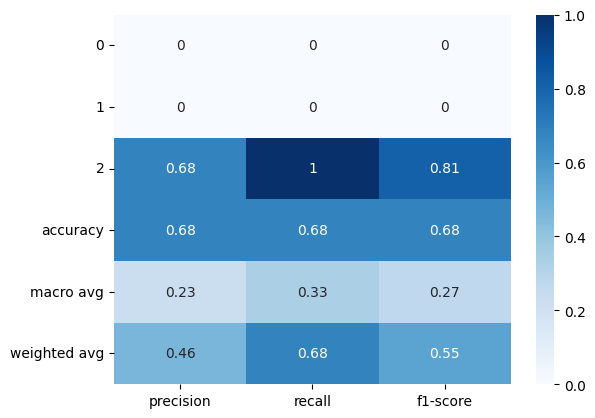

In [10]:
# Create a classification report and use seaborn to show it.
predictions_LSTM = best_model_LSTM.predict(X_test_LSTM)
clf_report_LSTM = classification_report(np.argmax(y_test_LSTM, axis = 1), np.argmax(predictions_LSTM, axis = 1), output_dict = True)


sns.heatmap(pd.DataFrame(clf_report_LSTM).iloc[:-1, :].T, annot=True, cmap="Blues")

<Axes: >

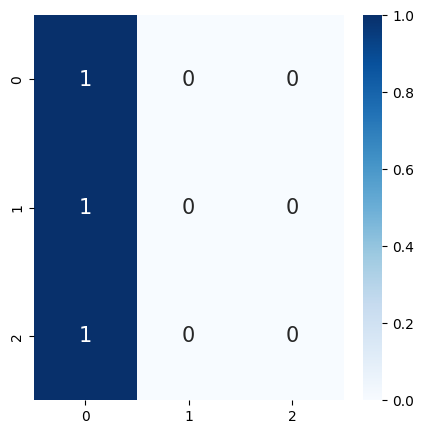

In [11]:
# Create a confusion matrix.
matrix_LSTM = confusion_matrix(y_test_LSTM.argmax(axis = 1), np.around(predictions_LSTM, decimals=0).argmax(axis = 1))

conf_matrix_LSTM = pd.DataFrame(matrix_LSTM, index = ['Neutral','Negative','Positive'],columns = ['Neutral','Negative','Positive'])
conf_matrix_LSTM = np.array(conf_matrix_LSTM).astype('float') / np.array(conf_matrix_LSTM).sum(axis = 1)[:, np.newaxis]
plt.figure(figsize = (5,5))
sns.heatmap(conf_matrix_LSTM, annot = True, annot_kws={"size": 15}, cmap = "Blues")

8/8 - 0s - 15ms/step - accuracy: 0.6800 - loss: 1.0645


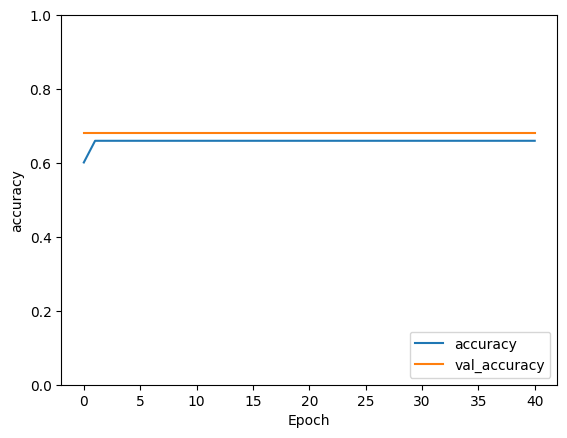

In [12]:
# Create a graph to check overfitting and underfitting.
plt.plot(history_LSTM.history['accuracy'], label='accuracy')
plt.plot(history_LSTM.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')

test_loss_LSTM, test_acc_LSTM = best_model_LSTM.evaluate(X_test_LSTM, y_test_LSTM, verbose=2)

#### KNN Model

We started with a KNN model that used the columns ``Review_Total_Negative_Word_Counts``, ``Review_Total_Positive_Word_Counts`` and ``Average_Score``. This got a result that only predicted based on how many positive or negative words there were, not the review text as the task asked for. In addition we also wanted to use the same data for all of our models so we swtiched our approach on KNN. After some testing we found that using ``TfidfVectorizer`` (Term Frequency-Inverse Document Frequency) was the right way to go:
* Term Frequency is how often a word appears in a text.
* Invers Document Frequency reduces the weight of common words across multiple documents while increasing the weight of rare words.
We used this to categorize the words into different levels of importance. We use the min_df = 5 to say that a word needs to be found at least 5 times to count.  
After some testing we used ``KNearestNeigbour`` with 13 neighbours and 20% of the data to train and the rest of the set to predict the result.

We evaluate the data with both a classification report and confusion matrix. We also check with a graph to calculate overfitting and/or underfitting.

Source: https://www.geeksforgeeks.org/understanding-tf-idf-term-frequency-inverse-document-frequency/


In [ ]:
# Convert labels to one-hot encoded labels.
labels_convert_KNN = np.argmax(labels_LSTM, axis=1)

In [ ]:
# Vectorize the reviews, use the same parameters as our Tokenizer for LSTM.
vectorizer = TfidfVectorizer(max_features = 5000, ngram_range = (1, 1), min_df = 5)
vectorize_reviews = vectorizer.fit_transform(X) 

In [ ]:
# Split the data into an 80% training and 20% test set. Set our random state to 42 to get a consistent result.
X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(vectorize_reviews, labels_convert_KNN, test_size = 0.2, random_state = 42)

In [ ]:
# After testing we found k=13 to be the best. In addition we found this model to be quite slow compared to the other models.
k = 13
model_KNN = KNeighborsClassifier(n_neighbors = k)
model_KNN.fit(X_train_KNN, y_train_KNN)
y_pred_train = model_KNN.predict(X_train_KNN)
y_pred_test = model_KNN.predict(X_test_KNN)

<Axes: >

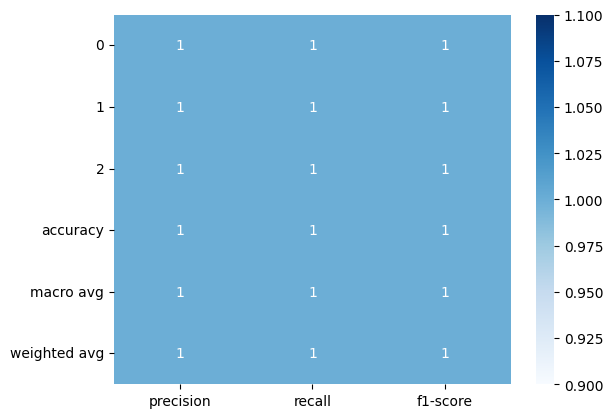

In [ ]:
# Create a classification report, show it using seaborn.
y_pred_KNN = model_KNN.predict(X_test_KNN)
clf_report_KNN = classification_report(y_test_KNN, y_pred_KNN, output_dict = True)

sns.heatmap(pd.DataFrame(clf_report_KNN).iloc[:-1, :].T, annot = True, cmap = "Blues")

<Axes: >

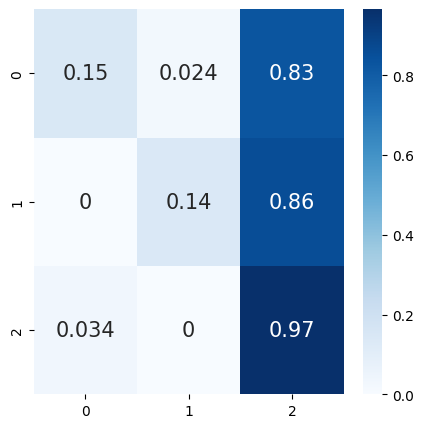

In [ ]:
# Create a confusion matrix.
matrix_KNN = sklearn.metrics.confusion_matrix(y_test_KNN, y_pred_KNN)
conf_matrix = pd.DataFrame(matrix_KNN, index = ['Neutral','Negative','Positive'],columns = ['Neutral','Negative','Positive'])
conf_matrix = np.array(conf_matrix).astype('float') / np.array(conf_matrix).sum(axis = 1)[:, np.newaxis]
plt.figure(figsize = (5,5))
sns.heatmap(conf_matrix, annot = True, annot_kws = {"size": 15}, cmap = "Blues")

Training Accuracy: 0.7
Testing Accuracy: 0.65

Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.13      0.19        45
           1       0.00      0.00      0.00        24
           2       0.69      0.95      0.80       131

    accuracy                           0.65       200
   macro avg       0.34      0.36      0.33       200
weighted avg       0.53      0.65      0.57       200



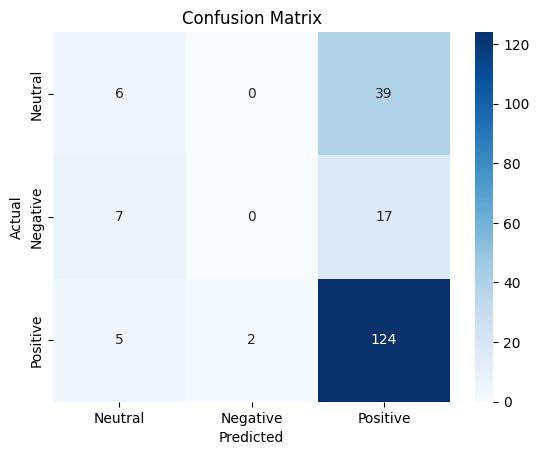

In [ ]:
# Calculating overfitting for KNN.

train_accuracy = accuracy_score(y_train_KNN, knn.predict(X_train_KNN))
test_accuracy = accuracy_score(y_test_KNN, y_pred_KNN)
overfitting = train_accuracy - test_accuracy

print(f'Overfitting: {overfitting}')

## TRENGS Å KJØRE PÅ NYTT, FEIL K


This output shows that the model is heavily leaning towards a positive result, where almost all of the entries is registerd as positive. The model also gives many false positives that should be neutral or false. The training set has a fairly high accuracy with ~69% correct and the actual testing set has an accuarcy of 66% which is also fairly high. The model also has low overfitting. 



#### NLP Model

We use this model since Natural Language Processing models are widely used when tackling sentiments analysis.

As per "Zubair Ashfaque" from "https://medium.com/@zubairashfaque/sentiment-analysis-with-naive-bayes-algorithm-a31021764fb4":  

__Sentiment Analysis with the Naive Bayes algorithm is a powerful approach, using probability and linguistic analysis to categorize text sentiments as positive, negative, or neutral. By preprocessing text, calculating log priors, and deriving log-likelihoods, this method quantifies sentiment, guiding accurate classification.__

<br>

After testing with `MultinomialNB` and `BernoulliNB` we found that `MultinomialNB` to have the best accuracy for our data. We also experimented with two vectorizers and found that `CountVectorizer` was a better fit for this model.

In [ ]:
# We use the same parameters as the TfdifVectorizer in the LSTM model, but our words also have to be in at least 5 reviews. We also only use words that appear in 60%
# of our reviews to remove non meaningful words.
cv = CountVectorizer(max_features = 5000, min_df = 5, max_df = 0.6)
X_nlp = cv.fit_transform(X)

X_train_NLP, X_test_NLP, y_train_NLP, y_test_NLP = train_test_split(X_nlp, y, test_size = 0.2, random_state = 42)

In [ ]:
# Train the model.
print("MultinomialNB:")
nlp_model = MultinomialNB()
nlp_model.fit(X_train_NLP, y_train_NLP)

MultinomialNB:


MultinomialNB()

{'negative': {'precision': 0.4375, 'recall': 0.5, 'f1-score': 0.4666666666666667, 'support': 14.0}, 'neutral': {'precision': 0.41379310344827586, 'recall': 0.2926829268292683, 'f1-score': 0.34285714285714286, 'support': 41.0}, 'positive': {'precision': 0.8387096774193549, 'recall': 0.896551724137931, 'f1-score': 0.8666666666666667, 'support': 145.0}, 'accuracy': 0.745, 'macro avg': {'precision': 0.5633342602892103, 'recall': 0.5630782169890665, 'f1-score': 0.5587301587301587, 'support': 200.0}, 'weighted avg': {'precision': 0.7235171023359288, 'recall': 0.745, 'f1-score': 0.7312857142857143, 'support': 200.0}}


<Axes: >

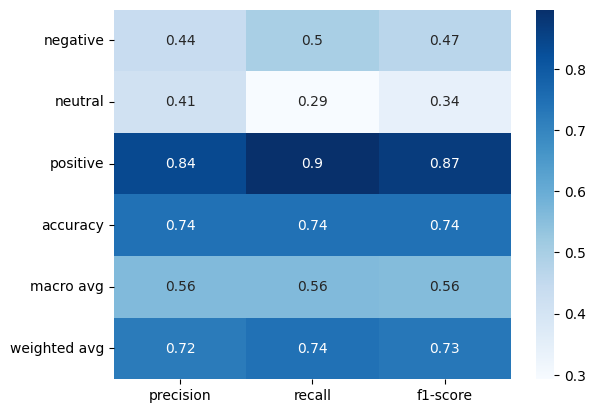

In [ ]:
# Creating a classification report.
y_pred_nlp = nlp_model.predict(X_test_NLP)
clf_report_NLP = classification_report(y_test_NLP, y_pred_nlp, output_dict = True)
print(clf_report_NLP)

sns.heatmap(pd.DataFrame(clf_report_NLP).iloc[:-1, :].T, annot = True, cmap = "Blues")

<Axes: >

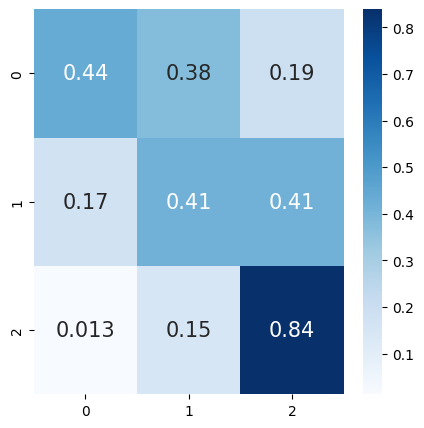

In [23]:
# Creating a confusion matrix
matrix_nlp = sklearn.metrics.confusion_matrix(y_pred_nlp, y_test_NLP)

conf_matrix = pd.DataFrame(matrix_nlp, index = ['Neutral','Negative','Positive'],columns = ['Neutral','Negative','Positive'])
conf_matrix = np.array(conf_matrix).astype('float') / np.array(conf_matrix).sum(axis = 1)[:, np.newaxis]
plt.figure(figsize = (5,5))
sns.heatmap(conf_matrix, annot = True, annot_kws = {"size": 15}, cmap = "Blues")

In [ ]:
# Calculating overfitting for KNN.

train_accuracy = accuracy_score(X_test_NLP, nlp.predict(X_train_NLP))
test_accuracy = accuracy_score(y_test_NLP, y_pred_nlp)
overfitting = train_accuracy - test_accuracy

print(f'Overfitting: {overfitting}')

#### CNN Model

We thought it would be cool to try and use a convolutional network for sentiment analysis of the reviews.

##### <u>Model note</u>
This model operates slightly differnt to the previous models, so it prepears and cleans the data a little bit different than the other models. It inherently does the same, but we will explain any deviation from the other models.

MYE AV DETTE KAN FLYTTES OPP

##### <u>Preparation</u>
This model loads the data on it's own, but fetches the exact same data as the other models. The model then concatenates the reviews and stores them in a variable, as well as storing the review scores in another. 

Further, the review score value is rounded and a category id is assigned to the review based on its score: 
* negative: 0 through 6 
* neutral: 7 through 8 
* positive: 9 through 10. 

Then the output category ids are one-hot encoded for each review.

The `dataset_preparation()` function handles the lemmatization of the words, removal of stop words and cleans the data. The data is returned in a clean state, together with the length of the review with the most words. 

##### <u>Vectorization</u>

The words are then converted to vectors to reduce processing time. The function `dataset_vectorization()` is used for this. The word-vectors cannot have just one channel with the word encoded into a number as an id representing it because of how gradient descent works. The neural network uses gradient descent, which assumes that the function is continuous, that the output interpolates smoothly between two input vectors, as the values of one vector interpolate into the other vector. This excludes id encoding, because words with ids close to each other are not at all guarranteed to have similar meanings, and for one dimension, it is basically impossible as the set of words grows, given that words have many "axies" of meaning.

One-hot encoding won't work either:
1. Because it would require a number of channels for the word-vector equal to the number of words. This excludes this approach because of how much memory and processing time it would require.

2. Because the input vectors would be far to sparse with meaning to draw anything out of, which is why this encoding style isn't used for these kinds of networks. //// SOURCE

One solution to this is turning the words into vectors using a system that can somehow figure out commonalities between the words or how they relate to each other or any kind of pattern, and then figure out a number of "axies" of meaning for each word. One such system is implemented by the `Word2Vec` class in `gensim`. It takes a model for vectorization and trains itself according to the model and a set of words provided. After this, a word can be inputted to the Word2Vec instance, and it will return an array of values. This array is the vector we use to represent the word, which we feed into the network. //// SOURCE

After this step, the array structure should look something like this:
```python
datasetX: [ [ [ float32, ... (k) ], ... (m) ] ... (n) ]
```
where `n` is the number of reviews, `m` is the length of the review, and `k` is the dimension of the word-vector.

We see that the reviews may have varying numbers of words, meaning that the arrays of word vectors would vary in length. To feed the array into the network, it needs to be converted to a tensor. The problem is that tensors are required to be like transcendentally rectangular, and the arrays of words varying in length is not comaptible with that. We did assume that a CNN with a convolutional layer as the input would be able to account for this, since the layer just strides from one end of the texture to the other, but apparently tensorflow doesn't like that.

# ==== IVAN Er dette riktig? =====
To solve this, I just padd the reviews to the length of the longest review, with word vectors where all the numbers are 0. This should be fine, since the vectorizer makes word vectors with values from -1 to 1, so 0 would be neutral; that the word vector has no meaning on that axis.
# ========================

The number of fragment channels was chosen based on testing. A larger number of channels consistently gave better results, and we assume that this trend would probably continue up until a number of channels that is some larger fraction of the total number of unique words in all the reviews, but more channels increases memory usage and training time, so we never really got to test this theory on the entire dataset. We assume that as the number of channels reaches past a quarter of all the unique words, the network would start to perform worse, since there would be too many channels and not enough words to generate meaning, leading to a similar situation as the one-hot encoding, that when it equals to the number of unique words, it would be equivalent to be like a padded out one-hot encoding. Again, we didn't get to actually test the one hot encoding, and we didn't get to test larger numbers of channels, so we can't really show data to attest to this theory.


##### <u>Defining the model</u>

The model uses a convolutional layer as input. The size and stride length of the filters was chosen based on testing. We found that these values were the ones that gave the best results. //// DOUBLE CHECK THIS: // A to small of a filter didn't perform very well. We theorize that this is because words in a sentence relate to each other across larger distances in a stream of speech or text, so a wider filter would do better. What we also saw was that when the filter was too large, it performed worse. We theorize that this is because words that are to far appart, don't mean much for each other, at least not as much as words that are close to each other, so they would mostly just be noise in the filter.

The 1D convolutional layer, gives a 2D output because there is a neuron for each channel of the fragments in the texture, so there is 1 dimension from the fragment channels and 1 dimension from the convolutional layer dimensionality. We use a flatten layer after the convolutional layer to turn the 2D output of the layer into a 1D output. All the outputs are kept in tact, just sequenced into a line.

We use a couple more layers after the convolutional layer to properly interpret the output of it and narrow it down to the three categories:
* positive 
* neutral
* negative

We use dropout layers in between the other layers, because by disregarding some of the inputs from one layer to the next, it makes the network more resilient. If a layer can't rely on the value of a neuron to always be usable, it has to find other patterns to reinforce, which makes the network spread the pattern recognition wider across the neurons in the layer.
//// SOURCE: https://medium.com/@utsavraj.ptn04/dropping-the-knowledge-bomb-understanding-dropout-layers-in-deep-learning-0612f517269d

The model uses early stopping in relation to loss. This is because if the model starts to perform worse with training, it is important to stop it when it is close to its peak. We have given the model a higher patience value, this is because we wanted it to try a little harder before giving up. This relates to the graphs that we saw, where accuracy tended to have some ups and downs, so the model should be a little more cool and levelheaded and hold the stocks a little longer. Also it was a bit sad to see the model give up after 10 out of 50 epochs.


In [25]:
#############
# DATAFRAME CONVERZZION

def dataframe_convertion(_dataset):
    _merged_reviews = []
    for i in _dataset.to_numpy():
        _merged_reviews.append({ "score": i[2], "review": i[0] + " " + i[1] })
    
    return _merged_reviews

In [26]:
#############
# DATASET EXTRAXXION

from typing import Iterable

def entry_extraction(_entry, _col):
    _entry_extract = []
    if isinstance(_entry[_col], Iterable):
        for _word in _entry[_col]:
            _entry_extract.append(_word)
        return _entry_extract
    else:
        return _entry[_col]

def dataset_extraction(_dataset, _col):
    _dataset_extract = []
    for _entry in _dataset:
        _entry_extract = entry_extraction(_entry, _col)
        _dataset_extract.append(_entry_extract)
    return _dataset_extract

In [27]:
#############
# DATASET PREPARATION

import re
import nltk
from nltk import WordNetLemmatizer

nonWords = nltk.corpus.stopwords.words("english");
nltk.download("stopwords");
nltk.download("punkt_tab");
nltk.download("wordnet");
lemma = nltk.WordNetLemmatizer();
stemma = nltk.PorterStemmer();

def stringClean( _string ):
    _string = _string.lower();
    _string = re.sub(r"\d+", "", _string);
    _string = re.sub(r"[^\w\s]", "", _string);
    return _string;

def lemmaBalls( _string ):
    _text = nltk.word_tokenize(_string);
    _textLemma = [];
    for _word in _text:
        _wordLemma = lemma.lemmatize(_word);
        if not (_wordLemma in nonWords):
            _textLemma.append(_wordLemma);
    return _textLemma;

def stemmaBalls( _string ):
    _text = nltk.word_tokenize(_string);
    _textStemma = [];
    for _word in _text:
        _word_lemma = WordNetLemmatizer().lemmatize(_word)
        if not _word_lemma in stop_words:
            _text_lemma.append(_word_lemma)
    return _text_lemma

def dataset_preparation(_dataset, _mode = "lemma"):
    _dataset_prepare = []
    _entry_longest = 0
    if _mode == "lemma":
        for _review in _dataset:
            _review_prepare = { "score": _review["score"], "review": lemma_string(string_clean(_review["review"])) }
            _dataset_prepare.append(_review_prepare)
            if len(_review_prepare["review"]) > _entry_longest:
                _entry_longest = len(_review_prepare["review"])
    else:
        raise ValueError("provided preparation mode does not exist")

    return _dataset_prepare, _entry_longest

In [28]:
#############
# SCORE: (abstract python decimal number) TO LABEL CONVERZZION

const_label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2,
}

const_score_map = {
     0: 0,
     1: 0,
     2: 0,
     3: 0,
     4: 0,
     5: 0,
     6: 0,
     7: 1,
     8: 1,
     9: 2,
    10: 2,
}

def entry_label_convertion( _score ):
    return const_score_map[round(_score)]

In [29]:
#############
# DATASET VECTORIZATION

from gensim.models import Word2Vec;
import random
import numpy as np

import random
import numpy as np

def datasetVectorization( _datasetX, _model, _fragmentChannels, _resolutionLargest = -1 ):
    _datasetVecc = [];
    for _review in _datasetX:
        _reviewVecc = entryVectorization(_review, _model, _fragmentChannels, _resolutionLargest);
        _datasetVecc.append(_reviewVecc);
    return _datasetVecc;


In [ ]:
#############
# LOGGING FUNXXION

import psutil

def log_memory():
    _10_power_2 = 1024
    _python = psutil.Process()
    print("  >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))


In [23]:
#############
# DO EVERYTHING

import pandas as pd

""" does the data very thoroughly, really properly does it

does data to following format:

n = number of reviews
m = number of words in review
k = number of channels per vectorized word

      dataset: [ entry, ... (n) ]
        entry: { "review": texture, "score": socre }
      texture: [ fragment, ... (m) ]
     fragment: [ colourChannel, ... (k) ]
colourChannel: float32
        score: [ boolean, boolean, boolean ]

dataset: [ [ [ [ float32, ... (k) ], ... (m) ], [ boolean, boolean, boolean ] ] ... (n) ]

datasetX: [ texture ... (n) ]
datasetY: [ score ... (n) ]

"""
def do_data(_path, _preparation_mode = "lemma", _fragment_channels = 100, _vectorization_mode = "skip", _pad_vectors = False):
    if _vectorization_mode != "skip" and _vectorization_mode != "bow":
        raise ValueError("provided vectorization mode does not exist")

    print("  # # started preparation")
    log_memory()
    
    print("        # loading from csv")
    _dataset = pd.read_csv(_path, usecols = ["Negative_Review", "Positive_Review", "Reviewer_Score"])
    log_memory()

    print("        # performing converzzion")
    _dataset = dataframe_convertion(_dataset)
    _dataset, _resolution_largest = dataset_preparation(_dataset, _mode = _preparation_mode)
    log_memory()

    print("        # performing extraxxion")
    _dataset_X = dataset_extraction(_dataset, "review")
    _dataset_Y = dataset_extraction(_dataset, "score")
    log_memory()
    _dataset = None
    log_memory()
    
    print("    # finished preparation")
    
    if not _pad_vectors:
        _resolution_largest = -1

    print("  # # started vectorization")
    
    print("        # training vectorization model")
    _model = None

    if _vectorization_mode == "skip":
        _model = Word2Vec(_dataset_X, min_count = 1, vector_size = _fragment_channels, window = 5, sg = 1)
    elif _vectorization_mode == "bow":
        _model = Word2Vec(_dataset_X, min_count = 1, vector_size = _fragment_channels, window = 5)
    else:
        raise ValueError("provided vectorization mode does not exist")
    log_memory()
    print("        # performing vectorization and splitting")
    
    if not _pad_vectors:
        _resolution_largest = -1

    print("  # # started vectorization")
    
    log_memory()
    print("    # finished vectorization")
    print("  # # outputting dataset")
    log_memory()
    return (
        _dataset_train_X,
        _dataset_test_X,
        _dataset_train_Y,
        _dataset_test_Y,
        _resolution_largest
    )

In [37]:
#############
# NETWORK: DEFINING /// COMPILING /// TRAINING

import tensorflow as tf
from tensorflow import keras
from keras import layers, datasets, models, callbacks
import numpy as np

def make_model(_dataset_train_X, _dataset_test_X, _dataset_train_Y, _dataset_test_Y, _resolution, _channels):
    print("    # started model")
    with tf.device("/GPU:0"):
        _model = models.Sequential()
        _model.add( layers.Input( shape = ( _resolution, _channels ), dtype = np.float32 ) )
       
        _model.add( layers.Conv1D(32, 8, activation = "relu", strides = 1, data_format = "channels_last"))
        _model.add( layers.Dropout(0.2))
        _model.add( layers.Dense(192, activation = "relu"))
        _model.add( layers.BatchNormalization())
        _model.add( layers.Flatten())
        _model.add( layers.Dropout(0.3))
        _model.add( layers.Dense(128, activation = "relu"))
        _model.add( layers.BatchNormalization())
        _model.add( layers.Dropout(0.2))
        _model.add( layers.Dense(64, activation = "relu"))
        _model.add( layers.BatchNormalization())
        _model.add( layers.Dropout(0.2))
        _model.add( layers.Dense(3, activation = "softmax"))
        _model.compile(
            optimizer = "adam",
            loss = keras.losses.CategoricalCrossentropy(from_logits = True),
            metrics = ["accuracy"],
        )

        _early_stopping = callbacks.EarlyStopping(monitor = "val_loss", patience = 20, restore_best_weights = True)

        _history = _model.fit(
            _dataset_train_X,
            _dataset_train_Y,
            batch_size = 128,
            epochs = 50,
            validation_data = (_dataset_test_X, _dataset_test_Y),
            callbacks = [_early_stopping],
        )
    print("    # model training finished")
    return _model, _history

In [10]:
#############
# EVALUATION /// VISUALIZATION
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def evaluate_model(_model, _dataset_test_X, _dataset_Test_Y):
    print("  # # evaluating model")
    _loss, _accuracy = _model.evaluate(_dataset_test_X,  _dataset_Test_Y, verbose = 0)

    print( "  >>> LOSS:     " + str(_loss), "\n  >>> ACCURACY: " + str(_accuracy) )

    _predictions = _model.predict(_dataset_test_X)
    _matrix = confusion_matrix(_dataset_Test_Y.argmax(axis = 1), np.around(_predictions, decimals = 0).argmax(axis = 1))
    print(classification_report(np.argmax(_dataset_Test_Y, axis = 1), np.argmax(_predictions, axis = 1)))

    _confusion_matrix = pd.DataFrame(_matrix, index = ["Negative","Neutral","Positive"], columns = ["Negative","Neutral","Positive"])
    print(_confusion_matrix)
    _10_power_2 = 1024
    _python = psutil.Process()
    print("      >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))

    return _confusion_matrix

def plotAll(_history, _confusion_matrix):
    plt.plot(_history.history["accuracy"], label = "accuracy")
    plt.plot(_history.history["val_accuracy"], label = "val_accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim([0.5, 1])
    plt.legend(loc = "lower right")
    plt.show()

    _confusion_matrix = np.array(_confusion_matrix).astype("float") / np.array(_confusion_matrix).sum(axis=1)[:, np.newaxis]
    plt.figure(figsize = (5, 5))
    sns.heatmap(_confusion_matrix, annot = True, annot_kws = {"size": 15})



  # # started preparation
  >>> memory usage: 1.31 gb
        # loading from csv
  >>> memory usage: 1.31 gb
        # performing converzzion
  >>> memory usage: 1.26 gb
        # performing extraxxion
  >>> memory usage: 1.26 gb
  >>> memory usage: 1.26 gb
    # finished preparation
  # # started vectorization
        # training vectorization model
  >>> memory usage: 1.27 gb
        # performing vectorization and splitting
  >>> memory usage: 1.31 gb
    # finished vectorization
  # # outputting dataset
  >>> memory usage: 1.31 gb
  >>> training data: 
      >>> textures (number of reviews): 
            4000 
      >>> _resolution (dimensions of texture in fragments): 
            200 
      >>> colour space dimensionality (channels per fragment): 
            64
    # started model
Epoch 1/50


c:\Users\ivans\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\backend\tensorflow\nn.py:666: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 178ms/step - accuracy: 0.4063 - loss: 1.3625 - val_accuracy: 0.3500 - val_loss: 1.1212
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 164ms/step - accuracy: 0.5430 - loss: 1.0220 - val_accuracy: 0.2780 - val_loss: 1.3476
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.5881 - loss: 0.9228 - val_accuracy: 0.2900 - val_loss: 1.2884
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.6163 - loss: 0.8781 - val_accuracy: 0.2910 - val_loss: 1.3162
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 164ms/step - accuracy: 0.6116 - loss: 0.8292 - val_accuracy: 0.2910 - val_loss: 1.2323
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step - accuracy: 0.6422 - loss: 0.7937 - val_accuracy: 0.2610 - val_loss: 1.2737
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 167ms/step - accuracy: 0.6640 - loss: 0.7484 - val_accuracy: 0.3250 - val_loss: 1.1560
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 164ms/step - accuracy: 0.6740 - loss: 0.7334 - val_accuracy: 0.387

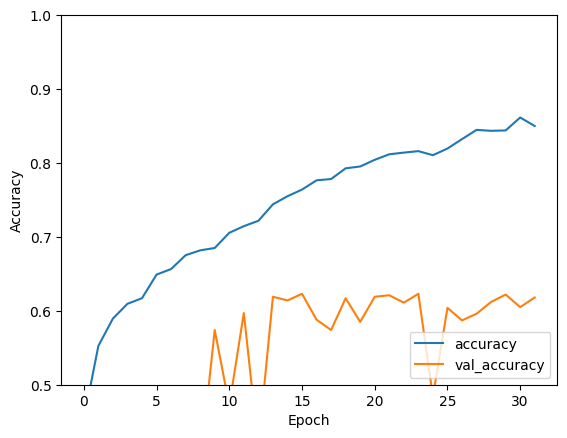

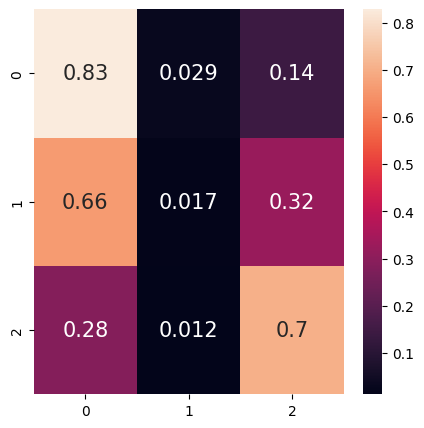

In [36]:
#############
# ACTUALLY DOING EVERYTHING

fragment_channels = 64

dataset_train_X, dataset_test_X, dataset_train_Y, dataset_test_Y, _resolution = do_data(
    "./Hotel_Reviews_small.csv",
    _fragment_channels = fragment_channels,
    _pad_vectors = True
)

print(
    "  >>> training data:",
    "\n      >>> textures (number of reviews):",
    "\n            " + str(len(dataset_train_X)),
    "\n      >>> resolution (dimensions of texture in fragments):",
    "\n            " + str(len(dataset_train_X[0])),
    "\n      >>> colour space dimensionality (channels per fragment):",
    "\n            " + str(len(dataset_train_X[0][0]))
)

confusion_matrix = evaluate_model(_model, dataset_test_X, dataset_test_Y)
plotAll(_history, confusion_matrix)

## dereferencing for garbage collection
dataset_train_X = None
dataset_test_X = None
dataset_train_Y = None
dataset_test_Y = None
_model = None
_history = None


# Task 2 Convolution Neural Network

##### Sources used to guide this task: 
* https://medium.com/x8-the-ai-community/solving-class-imbalance-problem-in-cnn-9c7a5231c478
* https://medium.com/@seelcs12/cnns-for-imbalanced-image-classification-with-tensorflow-7284a8c4a2e4


We start by loading the dataset from CIFAR-10 with all 60000 images. We split them into our training and test data. In addition we also normalize the images as it will be easier for our model to learn from.

In [ ]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

To create a binary CNN we first evaluated how the data is represented. As we scouted we find out we can change the labels into a binary relation that should make our data fit for our data. Before we can train a model we first have to choose a class as a our target, we chose frogs or label `[6]`.

In [ ]:
num_class = 6

for n in range(len(y_train)):
    if y_train[n] == [num_class]:
        y_train[n] = [1]
    else:
        y_train[n] = [0]

for n in range(len(y_test)):
    if y_test[n] == [num_class]:
        y_test[n] = [1]
    else:
        y_test[n] = [0]

#### Undersampling the data

After training and testing we found the dataset quite imbalanced for our task. As we only have 5000 frogs and 45000 non frogs, we decided to undersample our non frogs. But for our test data we decided to keep all the photos for better learning.

In [ ]:
x_tr_frog = []
y_tr_frog = []
for n in range(len(y_train)):
    if y_train[n] == [1]:
        x_tr_frog.append(x_train[n])
        y_tr_frog.append([1])

for n in range(len(y_train)):
    if len(x_tr_frog) < 10000:
        x_tr_frog.append(x_train[n])
        y_tr_frog.append([0])

x_tr_frog = np.array(x_tr_frog)
y_tr_frog = np.array(y_tr_frog)

##### <u>The model</u>

Create a function `make_model`. Start with 32 units of `Conv2D` with input size set to image size. Went with activation `relu`. Than a `BatchNormalization` which finds the optimal solution faster. Then reduce the size with `MaxPooling2D` to extract the valuable features. This is the base layer of the model, which we use two more times. In the last layer we start by `Flatten` to get one single vector. Then we add 128 units of `Dense` with the same activation. In addition we add a `kernel_regularizer` to help the models weights. We also add a `Dropout` layer for each `Dense` to prevent overfitting. Our last `Dense` will serve as our output and therefore we use the activation `sigmoid` to make the model create a score between 0 and 1. We also increased our `batch_size` to 128 to prevent spikes in our graph to check overfitting/underfitting. We also add an `early_stopping` to not waste time training.

In [93]:
def make_model(metric, x_train, y_train, x_val, y_val):
    with tf.device('/GPU:0'):
        model = models.Sequential()
        model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))

        model.add(layers.Conv2D(128, (3, 3), activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))

        model.add(layers.Conv2D(256, (3, 3), activation='relu'))
        model.add(layers.BatchNormalization())

        model.add(layers.Flatten())
        model.add(layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)))
        model.add(layers.Dropout(0.4))
        model.add(layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)))
        model.add(layers.Dropout(0.4))
        model.add(layers.Dense(1, activation='sigmoid'))

        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[metric])

        early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience = 5, restore_best_weights = True)

        history = model.fit(
            x_train,
            y_train,
            batch_size = 128,
            epochs = 50,
            validation_data = (x_val, y_val),
            callbacks = [early_stopping]
        )
        return model, history

In [ ]:
# Training the model. We chose accuracy as the metric as it performed better than other metrics.
acc_model, acc_history = make_model('accuracy', x_tr_frog, y_tr_frog, x_test, y_test)

In [ ]:
# Create a confusion matrix, uses seaborn to show it.
def made_predictions(predictions):
    array = []
    for pred in predictions:
        if max(pred) > 0.7:
            array.append([1])
        else:
            array.append([0])
    return np.array(array)

y_pred_acc = acc_model.predict(x_test)
y_pred_acc = made_predictions(y_pred_acc)
acc_cf = confusion_matrix(y_test, y_pred_acc)

sns.heatmap(acc_cf, annot=True, cmap='Blues', fmt='d')
fig.savefig('./matplotlib_data/conf_mat_CNN')
fig.show()

In [ ]:
# Create a graph to show overfitting and underfitting.
plt.plot(acc_history.history['accuracy'], label='accuracy')
plt.plot(acc_history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')
plt.savefig('./matplotlib_data/over_acc_CNN')

test_loss, test_acc = acc_model.evaluate(x_test, y_test, verbose=2)

#### Task 2b)

Found these pictures from Google:

* <u>Image 1</u>
    * https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.wcs.org%2Fget-involved%2Fupdates%2Ffascinating-frogs&psig=AOvVaw28_HGqOe7S2sxjPK3bsI5N&ust=1744278715616000&source=images&cd=vfe&opi=89978449&ved=0CBQQjRxqFwoTCKDFld_WyowDFQAAAAAdAAAAABAE

* <u>Image 2</u> 
    * https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.twinkl.pt%2Fteaching-wiki%2Ffrog&psig=AOvVaw0bdQuBJB9qO9gkRwCWvou-&ust=1744633397275000&source=images&cd=vfe&opi=89978449&ved=0CBQQjRxqFwoTCPCGuIGA1YwDFQAAAAAdAAAAABAE

* <u>Image 3</u>
    * https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.nytimes.com%2Fwirecutter%2Freviews%2Fnew-dog-checklist%2F&psig=AOvVaw2ZPUsP1HTJbZhOYM2tqHPx&ust=1744633423068000&source=images&cd=vfe&opi=89978449&ved=0CBQQjRxqFwoTCND_iI6A1YwDFQAAAAAdAAAAABAE

* <u>Image 4</u>
    * https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.goodwood.com%2Fgrr%2Ff1%2Fthe-nine-best-f1-cars-of-all-time%2F&psig=AOvVaw0_NSf08TH2_7ChAB8GfZhd&ust=1744633440992000&source=images&cd=vfe&opi=89978449&ved=0CBQQjRxqFwoTCNi76pWA1YwDFQAAAAAdAAAAABAE

Used Tensorflows own `load_img` to convert the pictures into the right size. Then we show them in the graph below. 

In [ ]:
# Showing the pictures we are using to test the models.
images = []

img_1 = tf.keras.utils.load_img('./media/frog_6.jpg', target_size=(32, 32))
img_2 = tf.keras.utils.load_img('./media/frog_4.jpg', target_size=(32, 32))
img_3 = tf.keras.utils.load_img('./media/dog_2.jpg', target_size=(32, 32))
img_4 = tf.keras.utils.load_img('./media/f1.jpg', target_size=(32, 32))

images.append(img_1)
images.append(img_2)
images.append(img_3)
images.append(img_4)

fig, ax = plt.subplots(2, 2)
fig.tight_layout()
ax = ax.flatten()

images_for_model = []
num = 1

for img, ax in zip(images, ax):
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.array(img_array) / 255.0 # Normalize
    images_for_model.append(img_array)
    ax.imshow(img_array)
    ax.set_title(f'Image {num}')
    ax.axis('off')
    num += 1

plt.show()

##### <u>Prediction</u>

When making our predictions we first add a batch to the picture so our model can actually use it to evaluate. When the model makes a prediction we convert it into a percentage for better reading. We add a threshold to decide if we are going to believe the model or not. We found 70% worked nicely, print out the result.

In [ ]:
# Actual predictions
print("Hi! I'm Accuracy and I think that: ")
for num in range(len(images_for_model)):
    img = images_for_model[num]
    img = tf.expand_dims(img, 0) # Create a batch
    pred = acc_model.predict(img)
    pred = pred[0][0] * 100
    print(f"    Image {num + 1} is: ", end="")
    if pred > 70:
        print(f'{pred:.2f}% a frog.')
    else:
        print(f'{100 - pred:.2f}% not a frog')

### Conclusion of task 1.

...

### Conclusion of task 2.

To summarize short we have create a binary CNN model to predict if a picture is a frog or not. In addition we have optimized most of our model through testing and created an optimal solution to the task. Lastly we also tested the model with pictures from the internet to test our model which worked quite nicely.